# 本节操作-数据操作

## 张量操作

In [43]:
import torch

创建一个张量

In [3]:
x=torch.arange(12)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

张量表示一个由数值组成的数组，这个数组可能有多个维度。 具有一个轴的张量对应数学上的向量（vector）； 具有两个轴的张量对应数学上的矩阵（matrix）； 具有两个轴以上的张量没有特殊的数学名称。

查看张量的大小维度

In [4]:
torch.Size(x)

torch.Size([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [5]:
x.shape

torch.Size([12])

查看张量之中元素的总数

In [6]:
x.numel()

12

重塑张量的维度

In [7]:
re_x=x.reshape(3,4)
print(re_x)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [8]:
re_x.numel(),re_x.shape

(12, torch.Size([3, 4]))

创建全为0/1的多维度张量

In [9]:
# 创建全为0的[2,3,4]张量
mut_0=torch.zeros((2,3,4))
print(mut_0)
# 创建全为1的[2,3,4]张量
mut_1=torch.ones((2,3,4))
print(mut_1)

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])


随机初始化参数

有时我们想通过从某个特定的概率分布中随机采样来得到张量中每个元素的值。 例如，当我们构造数组来作为神经网络中的参数时，我们通常会随机初始化参数的值。 以下代码创建一个形状为（3,4）的张量。 其中的每个元素都从均值为0、标准差为1的标准高斯分布（正态分布）中随机采样。

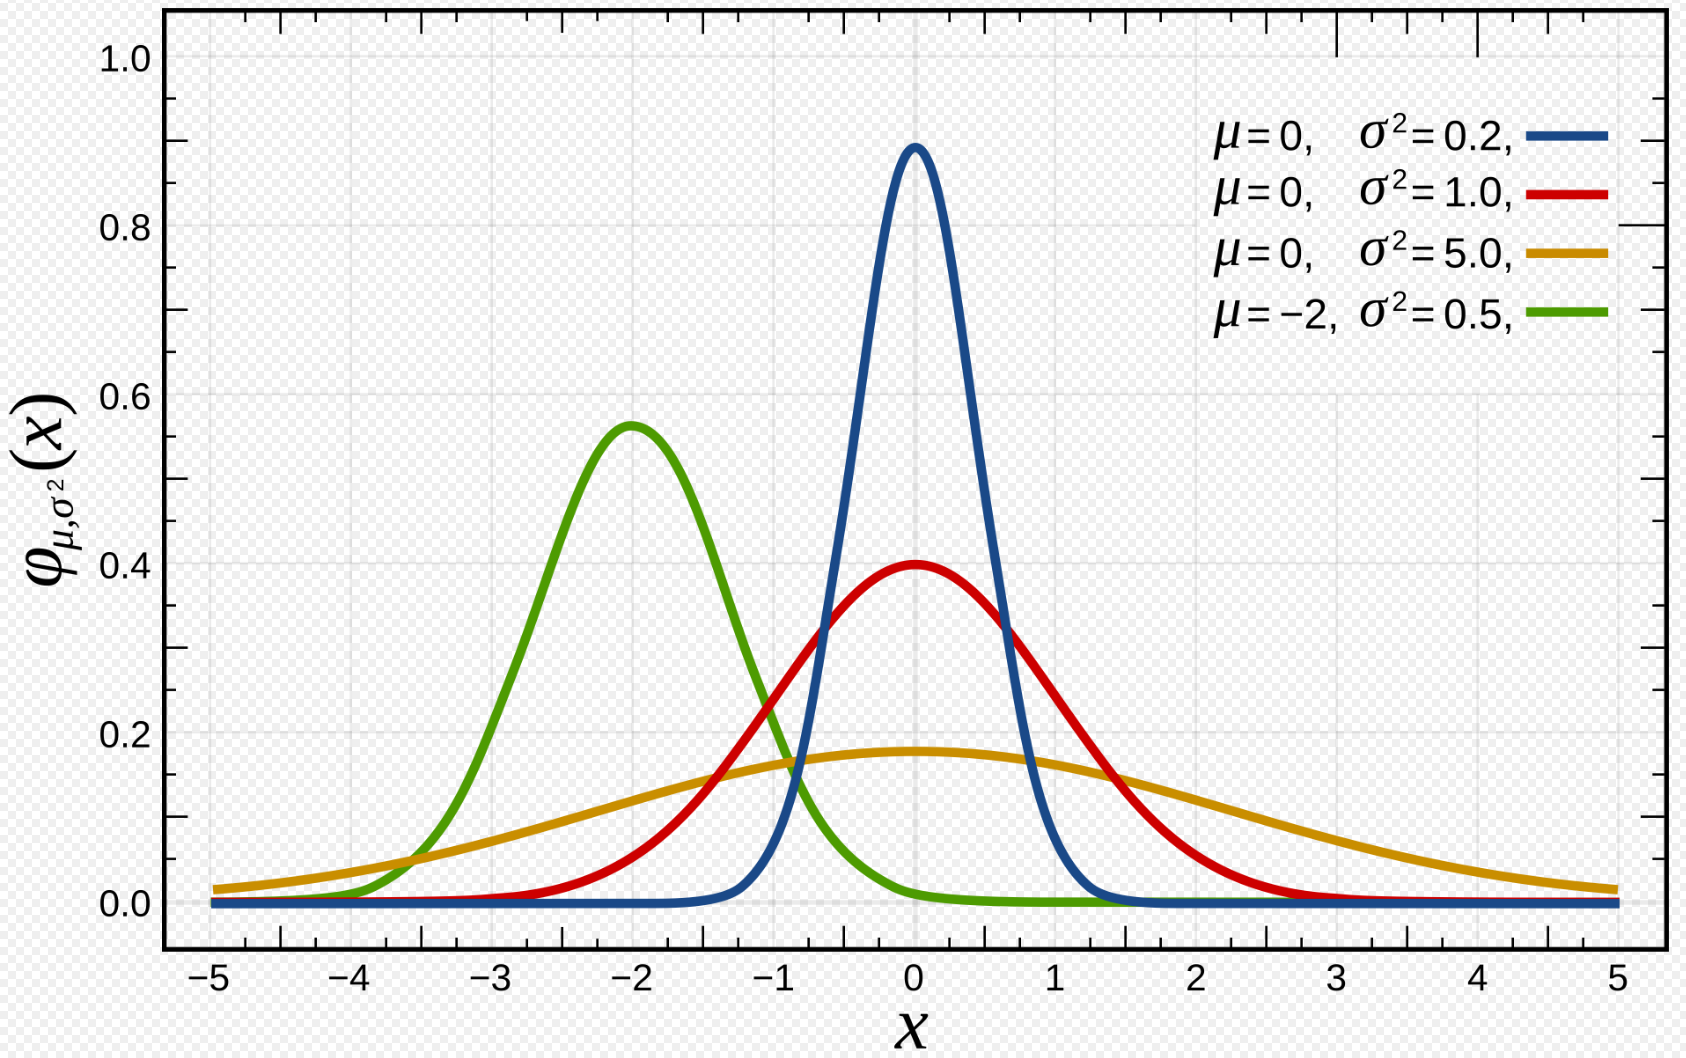

In [10]:
# 初始化一个[3,4]的矩阵，矩阵之中的值均值为0、标准差为1的标准高斯分布（正态分布）之中
torch.randn(3,4)

tensor([[ 0.7507, -0.7175,  1.2621,  0.1792],
        [-0.1415,  0.1770,  0.2103, -0.8480],
        [-0.2277, -0.5215,  0.2422,  0.3766]])

我们还可以通过提供包含数值的Python列表（或嵌套列表），来为所需张量中的每个元素赋予确定值。 在这里，最外层的列表对应于轴0，内层的列表对应于轴1。

In [11]:
res=torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
print(res)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


## 运算符

对于将两个数组作为输入的函数，按元素运算将二元运算符应用于两个数组中的每对位置对应的元素。 我们可以基于任何从标量到标量的函数来创建按元素函数。

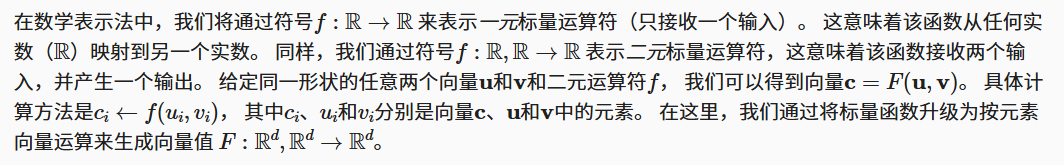

In [12]:
import torch

In [13]:
# 得到张量x
x=torch.tensor([1,2,3,4,5,6])
# print(x)
# 得到张量y
y=torch.tensor([1,2,3,4,5,6])
# print(y)
x+y,x-y,x*y,x/y,x**y

(tensor([ 2,  4,  6,  8, 10, 12]),
 tensor([0, 0, 0, 0, 0, 0]),
 tensor([ 1,  4,  9, 16, 25, 36]),
 tensor([1., 1., 1., 1., 1., 1.]),
 tensor([    1,     4,    27,   256,  3125, 46656]))

In [14]:
x.shape,y.shape

(torch.Size([6]), torch.Size([6]))

In [15]:
# 幂运算
torch.exp(x)

tensor([  2.7183,   7.3891,  20.0855,  54.5981, 148.4132, 403.4288])

张量更复杂的创建方式

In [16]:
# 创建x张量
x_data=torch.arange(12,dtype=torch.float).reshape(3,4)
# 创建y张量
y_data=torch.tensor([[1,2,3,4],[5,6,7,8],[9,10,11,12]])
# 按照行进行合并，此时dim=0
z_data_1=torch.cat([x_data,y_data],dim=0)
# 按照列进行合并，此时dim=1
z_data_2=torch.cat([x_data,y_data],dim=1)
# 打印输出按照行合并结果，按照列合并结果
z_data_1,z_data_2

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 1.,  2.,  3.,  4.],
         [ 5.,  6.,  7.,  8.],
         [ 9., 10., 11., 12.]]),
 tensor([[ 0.,  1.,  2.,  3.,  1.,  2.,  3.,  4.],
         [ 4.,  5.,  6.,  7.,  5.,  6.,  7.,  8.],
         [ 8.,  9., 10., 11.,  9., 10., 11., 12.]]))

快速判断两个张量的数值是否相同，使用`==`符号，会返回一个状态矩阵，在比较过程之中，会对两个张量对应位置的元素，如果相同，就在状态矩阵的当前位置设置为`True`，反之设置为`False`。

In [17]:
x_judge=torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
y_judge=torch.tensor([[-1,1,3],[4,5,-1],[7,8,9]])
judge=x_judge==y_judge
print(judge)

tensor([[False, False,  True],
        [ True,  True, False],
        [ True,  True,  True]])


通过`torch.sum(tensor)`方法，来对张量之中的元素进行求和处理

In [18]:
res_sum=torch.sum(judge)
res_sum,torch.sum(x_judge),torch.sum(y_judge)

(tensor(6), tensor(45), tensor(35))

## 广播机制

广播机制主要是为了应对不同维度的张量之间的运算。

上述代码之中，我们已经看到了当两个张量维度相同时，应该如何进行运算，现在介绍的广播机制，就是为了应对，当两个张量维度不想同时，应该如何进行运算。

执行步骤：

- 第一步：通过复制操作使得两个张量具有相同的形状
- 第二步：对两个张量分别按照元素进行操作

In [19]:
a=torch.tensor([1,2,3]).reshape(3,1)
b=torch.tensor([5,6]).reshape(1,2)
a,b,a+b

(tensor([[1],
         [2],
         [3]]),
 tensor([[5, 6]]),
 tensor([[6, 7],
         [7, 8],
         [8, 9]]))

由于a和b分别是（3，1）和（1，2）矩阵，如果让它们相加，它们的形状不匹配。 我们将两个矩阵广播为一个更大的（3，2）矩阵，如下所示：矩阵a将复制列， 矩阵b将复制行，然后再按元素相加。

## 索引和切片

索引操作

In [22]:
# 创建操作张量 res
res=torch.arange(12).reshape(2,6)
print(res)
# 通过索引进行切片操作
# 索引的第一个参数代表行索引，第二个参数代表列索引
s1=res[-1,2:4]
print(s1)
# 通过索引进行下标访问
data_child=res[1,2]
print(data_child,type(data_child))
res[1,2]=-1
re_data_child=res[1,2]
print(data_child,re_data_child)
# 多个元素同时赋值
res[1,2:4]=-100
print(res)

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
tensor([8, 9])
tensor(8) <class 'torch.Tensor'>
tensor(-1) tensor(-1)
tensor([[   0,    1,    2,    3,    4,    5],
        [   6,    7, -100, -100,   10,   11]])


## 节省内存

复制一个新的张量

In [32]:
# 初始化测试张量
data_mul=torch.tensor([1,2,3,4]).reshape(2,2)
# 浅复制，存储地址相同，本质上是同一张量
copy_data_mul=data_mul
print(id(data_mul),id(copy_data_mul),id(data_mul)==id(copy_data_mul))
# 深复制，存储地址不同，本质上是不同的张量
deep_copy_data_mul=torch.zeros_like(data_mul)
print(id(data_mul),id(deep_copy_data_mul),id(data_mul)==id(deep_copy_data_mul))

2913264118720 2913264118720 True
2913264118720 2913264117824 False


## 转换为其它`Python`对象


- `A.numpy()`：转换为`numpy`数组
- `torch.tensor(A)`：转换为`tensor`张量类型

In [42]:
A=torch.arange(12).reshape(3,4)
# 将A转换为numpy数组
B=A.numpy()
# 将B转换为张量类型
C=torch.tensor(B)
# A,B,C
type(A),type(B),type(C)

(torch.Tensor, numpy.ndarray, torch.Tensor)